In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Loan Approval Prediction Model

### <u>**Business Context**</u>
In today's fast-paced financial world, loan approval is a critical aspect of banking and lending institutions. Traditionally, loan approvals have been heavily dependent on manual assessments, where loan officers examine credit histories, income reports, and other personal factors to determine whether an applicant is eligible for a loan. While this approach has been effective in certain cases, it can be inefficient, prone to human error, and often results in inconsistent decision-making. This process can also be time-consuming for both the applicants and the institutions, leading to long waiting periods and sometimes missed opportunities.
With the advent of data analytics and machine learning, financial institutions have begun to explore automation for improving loan approval processes. Machine learning models can process vast amounts of data to make informed decisions, providing a more objective, faster, and consistent approach to loan approval. The integration of these advanced technologies is not only expected to streamline workflows but also to enhance the accuracy of predicting the likelihood of loan repayment.
A key challenge, however, lies in developing a predictive system that can balance the complexities of human financial behavior and existing data patterns. The objective of the Loan-Approval-Prediction system is to build such a solution—an automated, reliable, and scalable model that can predict the approval or rejection of loan applications based on several historical and real-time data points.
The ultimate aim of implementing such a system is to minimize the time spent on each loan decision while maintaining high accuracy, reducing biases, and making the process fairer for all applicants. In doing so, lending institutions can improve their operations, provide quicker responses to applicants, and increase overall customer satisfaction.

### <u>**Problem Statement**</u>
Loan approval prediction poses a unique challenge due to the multifaceted nature of the factors that influence an applicant’s ability to repay a loan. Traditionally, loan officers have relied on a set of criteria—such as credit score, income level, age, and past loan repayment history—when determining the risk associated with lending money to an individual. However, this process often lacks objectivity and is subject to human bias, where subjective interpretations of the data can lead to unfair or inconsistent decisions. Additionally, the sheer volume of loan applications in large financial institutions makes it increasingly difficult for human evaluators to maintain accuracy and efficiency.


The primary problem to address in this case study is the creation of an automated predictive model capable of accurately forecasting whether a given loan application will be approved or rejected. The model should take into account a variety of features that can significantly affect the loan decision, including:

**Demographic factors:** Age, marital status, education level, and employment status, which often influence an applicant's financial stability and future earning potential.

**Credit-related factors:** Credit score, outstanding debts, and the applicant’s credit history, which are indicative of how reliable an individual has been in repaying previous debts.

**Financial factors:** Monthly income, loan amount, loan term, and debt-to-income ratio, which provide insight into an applicant’s ability to manage additional financial commitments.

**Behavioral and socio-economic factors:** Housing situation, type of employment, and other lifestyle-related information that can impact the applicant’s long-term financial behavior.

The traditional approach of loan approval heavily relies on the judgment of loan officers to interpret these factors and make decisions, which can often result in subjective and biased outcomes. The key problem this project seeks to address is automating this decision-making process using machine learning, ensuring that decisions are made based on data-driven insights rather than human judgment alone.

Furthermore, the model must be able to handle missing or incomplete data, as applicants may not always provide a full set of information. It should also account for the dynamic nature of financial conditions, adjusting predictions based on changes in an applicant’s financial standing over time.

In [3]:
data = pd.read_csv('loan_approval_dataset.csv')

In [4]:
data.drop(columns = ['loan_id'], inplace=True)

In [5]:
data.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [6]:
data.columns = data.columns.str.strip()

In [7]:
data.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [8]:
data.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [9]:
data.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

#### Check for missing data

In [10]:
data.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [11]:
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


#### Check for duplicate

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data.education.unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [14]:
def clean_data(st):
    st = st.strip()
    return st

In [15]:
clean_data(' Graduate')

'Graduate'

In [16]:
data.education = data.education.apply(clean_data)

In [17]:
data.education.unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [53]:
data['education'] = data['education'].replace(['Graduate', 'Not Graduate'],[1,0])

In [19]:
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [20]:
data.self_employed.unique()

array([' No', ' Yes'], dtype=object)

In [21]:
data.self_employed = data.self_employed.apply(clean_data)

In [22]:
data.self_employed.unique()

array(['No', 'Yes'], dtype=object)

In [54]:
data.self_employed = data.self_employed.replace(['No', 'Yes'],[0,1])

In [24]:
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [25]:
data.loan_status.unique()

array([' Approved', ' Rejected'], dtype=object)

In [26]:
data.loan_status = data.loan_status.apply(clean_data)

In [27]:
data.loan_status.unique()

array(['Approved', 'Rejected'], dtype=object)

In [55]:
data.loan_status = data.loan_status.replace(['Approved', 'Rejected'],[1,0])

In [29]:
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,0,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,0,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


In [30]:
# split feature based on data type
target_col = "loan_status"
df_num = data.select_dtypes(include=["int64"]).drop(columns=[target_col])
df_num_col = df_num.columns
df_obj = data.select_dtypes(include=["object"])
df_obj_col = df_obj.columns

#### Check features distribution plot

In [31]:
print(f"numeric columns: {len(df_num_col)}")

numeric columns: 11


In [32]:
binary_cols = [c for c in df_num_col 
               if set(data[c].dropna().unique()).issubset({0, 1})]

In [33]:
plot_cols = [c for c in df_num_col if c not in binary_cols]

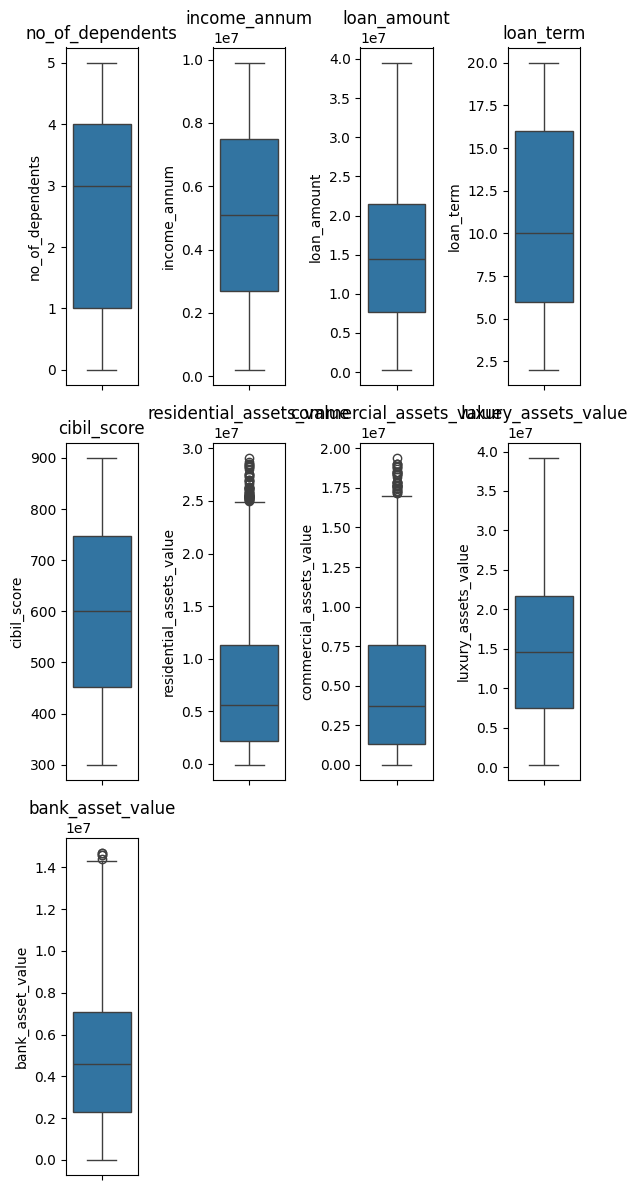

In [34]:
import math

n = len(plot_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(6, 4 * rows))

for i, col in enumerate(plot_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=data[col], orient="v")
    plt.title(col)

plt.tight_layout()
plt.show()

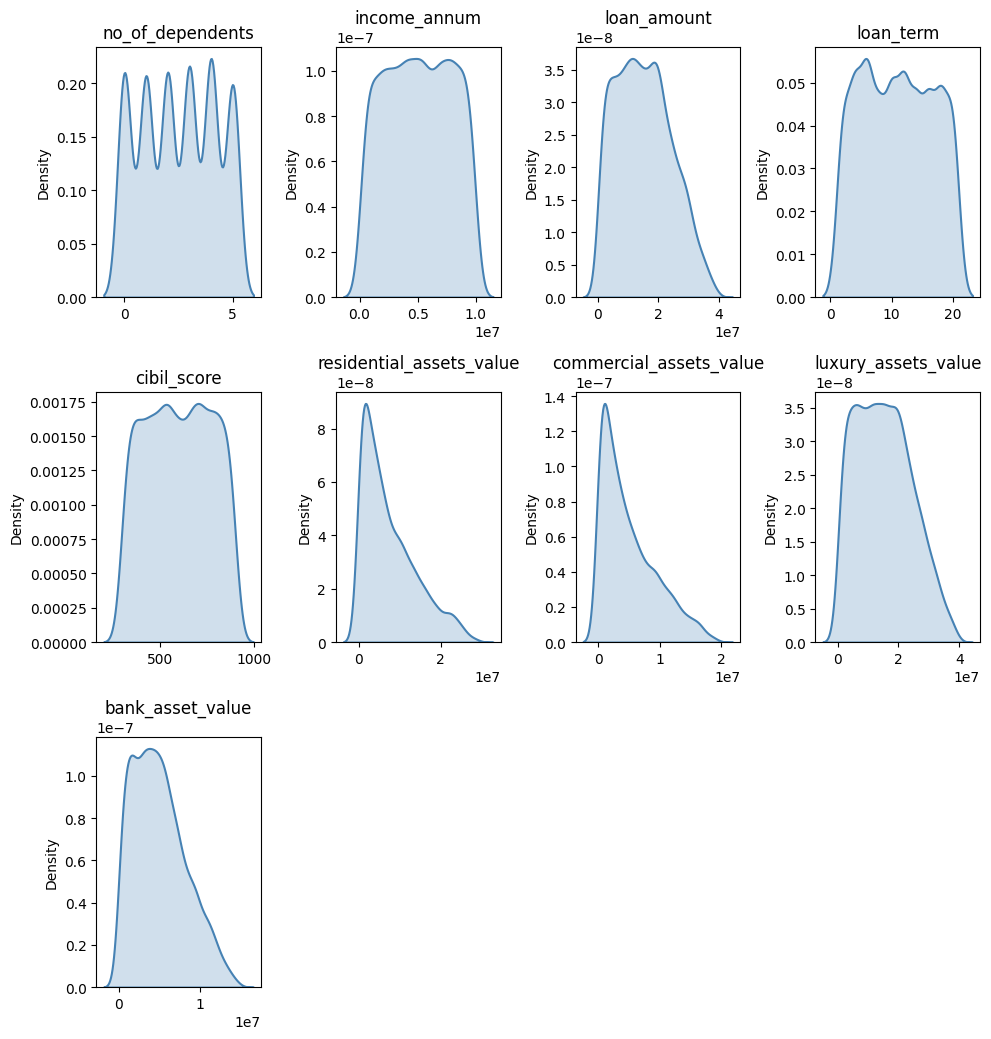

In [35]:
# KDE plot
# 1. Identify binary 0/1 columns
binary_cols = [
    c for c in df_num_col
    if set(data[c].dropna().unique()).issubset({0, 1})
]

# 2. Columns to plot (non-binary numeric columns)
plot_cols = [c for c in df_num_col if c not in binary_cols]

# 3. Subplot layout
n = len(plot_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(10, 3.5 * rows))

# 4. KDE plots
for i, col in enumerate(plot_cols):
    plt.subplot(rows, cols, i + 1)
    sns.kdeplot(data[col], fill=True, color="steelblue", linewidth=1.5)
    plt.title(col)
    plt.xlabel("")
    plt.tight_layout()

plt.show()


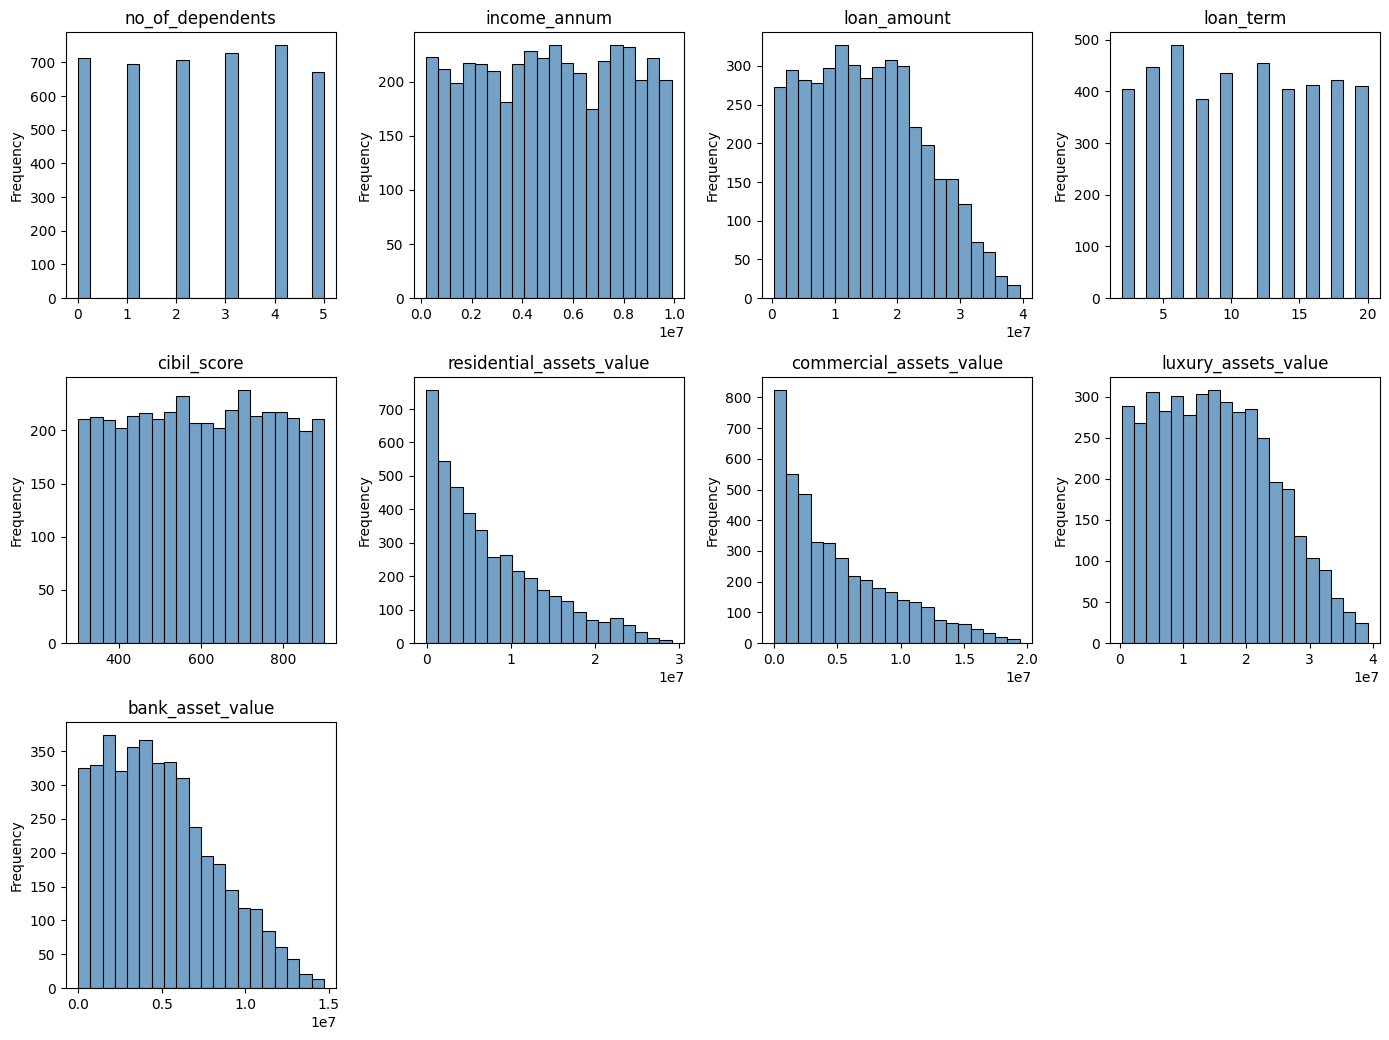

In [36]:
# Histogram plot

# 1. Identify binary 0/1 columns
binary_cols = [
    c for c in df_num_col
    if set(data[c].dropna().unique()).issubset({0, 1})
]

# 2. Columns to plot (non-binary numeric columns)
plot_cols = [c for c in df_num_col if c not in binary_cols]

# Subplot layout
n = len(plot_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(14, 3.5 * rows))

# Loop over columns and plot histogram
for i, col in enumerate(plot_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(data[col], bins=20, kde=False, color="steelblue")
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### Check for outliers

In [37]:
for col in df_num_col:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

no_of_dependents: 0 outliers
education: 0 outliers
self_employed: 0 outliers
income_annum: 0 outliers
loan_amount: 0 outliers
loan_term: 0 outliers
cibil_score: 0 outliers
residential_assets_value: 52 outliers
commercial_assets_value: 37 outliers
luxury_assets_value: 0 outliers
bank_asset_value: 5 outliers


Outlier analysis using the IQR method identified some extreme values in 3 features: `residential_assets_value`, `luxury_assets_value`, and `bank_asset_value`. However, these points are not isolated anomalies; they fall within the natural long tails of the distribution. This suggests that the dataset is **skewed** rather than containing erroneous records. Therefore, the outliers likely represent valid high-value cases and will be retained for modeling.

### <u>**Data/Feature Pre-processing**</u>
#### Feature Scaling And Train Test Splitting

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
##input_data = data.drop(columns=['loan_status'])
##output_data = data['loan_status']

In [40]:
##input_data
features = [
    "no_of_dependents", "education", "self_employed", "income_annum",
    "loan_amount", "loan_term", "cibil_score"
]

In [41]:
##output_data
X = data[features].copy()
y = data["loan_status"]

In [42]:
#x_train,x_test,y_train,y_test = train_test_split(input_data,output_data, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

### <u>**Modeling**</u> 
#### Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

### <u>**Evaluation**</u>

In [48]:
print("Accuracy :", accuracy_score(y_test, y_pred)) #how many prediction were correct from the total
print("Precision:", precision_score(y_test, y_pred)) #all the positive predictions that models has made, from how many were actually positive
print("Recall   :", recall_score(y_test, y_pred)) #from the actual positives how many were model was able to identify
print("F1-score :", f1_score(y_test, y_pred)) #mean b/w recall and precision. 
print("ROC-AUC  :", roc_auc_score(y_test, y_proba)) # 0 - 1, if towasrds 1, the model is good. if 0.5 (random guessing)

Accuracy : 0.819672131147541
Precision: 0.8168067226890756
Recall   : 0.9152542372881356
F1-score : 0.8632326820603907
ROC-AUC  : 0.8941654568458366


In [49]:
print("Logistic Regression: \n", classification_report(y_test, y_pred))

Logistic Regression: 
               precision    recall  f1-score   support

           0       0.83      0.66      0.74       323
           1       0.82      0.92      0.86       531

    accuracy                           0.82       854
   macro avg       0.82      0.79      0.80       854
weighted avg       0.82      0.82      0.81       854



In [50]:
#Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[214 109]
 [ 45 486]]


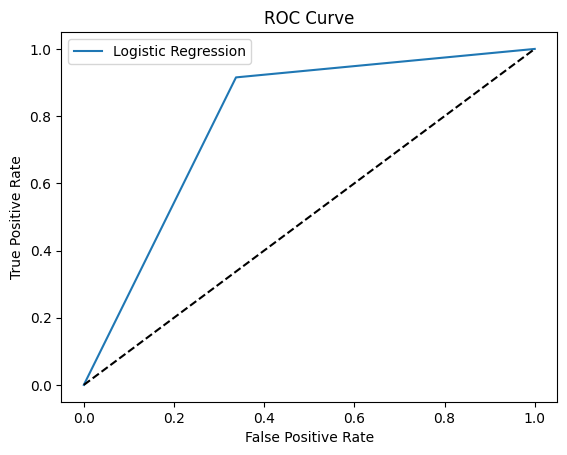

In [52]:
#Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [51]:
example = [[
    2,      # no_of_dependents
    1,      # education [yes]
    1,      # self_employed [yes]
    4100000,      # income_annum 
    15200000,      # loan_amount (Yes=1)
    12,     # loan_term (months)
    700   # cibil_score
]]

pred_prob = model.predict_proba(example)[0, 1]
pred_class = model.predict(example)[0]

print("Predicted loan_status probability:", pred_prob)
print("Predicted class (1=Approved, 0=Rejected):", pred_class)

Predicted loan_status probability: 0.9257746050074023
Predicted class (1=Approved, 0=Rejected): 1


C:\Users\Shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### <u>**Conclusion**</u>

The logistic regression model was used to predict the likelihood of loan approval based on applicant features. For the tested applicant:

- Predicted probability of approval: 0.926 (~93%)
- Predicted class: Approved

**Key Takeaways:**

- The applicant shows a high likelihood of loan approval based on their credit profile and financial features.
- The predicted probability provides a confidence measure, allowing decision-makers to prioritize high-probability applications.
- This predictive model can be extended to evaluate multiple applicants, helping streamline the loan approval process and reduce manual effort.

**Overall:**

The model demonstrates that data-driven approaches can support faster, more consistent, and reliable loan decision-making.

### <u>**Limitation and Future Improvements**</u>

#### Limitation:
- **Approval Bias Replication:**
  <br>
  The model only learns from past approval decisions. If historical approvals contained bias (e.g., towards/against certain demographics, job types, or income levels), the model will replicate and reinforce those biases.
- **No Default Information:**
  <br>
  The dataset only tracks approval/rejection decisions, not whether borrowers repaid or defaulted. Thus, the model cannot evaluate financial risk or creditworthiness. It only mimics past approval patterns.

#### Future Improvements:
- **Integrate Repayment Outcomes:**
  <br>
  By including repayment/default data, the model could predict not just who *gets approved*, but also who is *likely to repay successfully*. This could directly minimize default rates and losses.
- **Model Calibration:**
  <br>
  Fine-tune the decision threshold to balance approval rate, depending on the bank's strategy.